# Assignment 5: US midterm issues, sentiment, sweep odds and a mid-term basket

This notebook reproduces every table and figure in `REPORT.pdf`. It does not pull data itself: the collectors and scorers are `scripts/01` to `07`, and they write to `data/`. The first code cell re-runs `scripts/08_run_analysis.py` (all tables and `outputs/results.json`) and `scripts/09_make_figures.py` (all figures) on the saved data, so everything shown below is computed here, the same way as for the report.

Each section below starts with the report's own text for that section (copied from `REPORT.md` when the notebook is built), and then shows the tables behind it. After each figure block there is a short "How these figures are made" cell.

In [1]:
import sys, json, warnings, subprocess
sys.path.insert(0, '.'); sys.path.insert(0, 'scripts')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 180); pd.set_option('display.max_columns', 30)
from src.config import TABLES, FIGURES, OUTPUTS, PREREG, PREREG_DEVIATION
# recompute every table and figure from the saved data, exactly as for the report
for s in ['scripts/08_run_analysis.py', 'scripts/09_make_figures.py']:
    r = subprocess.run([sys.executable, s], capture_output=True, text=True)
    print(s, 'exit', r.returncode)
    assert r.returncode == 0, r.stderr[-2000:]
R = json.loads((OUTPUTS / 'results.json').read_text())
print('key topics:', R['q1']['key_topics'])

scripts/08_run_analysis.py exit 0


scripts/09_make_figures.py exit 0
key topics: ['Foreign policy & Iran war', 'Democracy & rule of law', 'Abortion & social issues', 'Immigration & deportations', 'Taxes, budget & spending', 'Health care', 'Trump & the administration', 'Government ethics & corruption']


# Assignment 5 report

### US Midterm Issues, Sentiment, Democratic Sweep Odds and a Mid-Term Basket: Jul 1 to Oct 7, 2026

FRE-GY 7871 A · NLP and the Investment Process

**Name:** Aditya Gupta
**NetID:** ag11023
**GitHub repo:** https://github.com/Aditya-Gupta26/FRE_GY_7871_Assignment_5

---

## 1. What I did

The midterms are on Nov 3, 2026. Republicans hold the White House, the House (218 R, 214 D, 1 I) and the Senate (53 R, 47 D incl. 2 independents), so a "Democratic sweep" needs a net gain of 3 House seats and 4 Senate seats (VP Vance breaks a 50-50 tie). My window is Jul 1 to the Oct 7 close (99 calendar days, 69 trading days).

**Data.** From social media I collected **31,540 tweets** (twitterapi.io) and, in addition to Twitter, also **143,625 Reddit posts and comments** from six political subreddits (Arctic Shift); 25,743 and 40,148 survive the filters. From news, **72,688 unique election headlines** (Google News RSS): 69,282 from 30 named outlets and 3,406 from Google News' US feed (1,118 other sites). The sweep odds are Polymarket's "Democrats Sweep" contract and Kalshi's `KXBALANCEPOWERCOMBO-27FEB-DD`, hourly, snapshotted at 16:00 ET. Prices for 27 stocks and 10 ETFs or futures come from yfinance. I ran BERTopic with an LLM (Claude subagents) naming the issues, built a validated directional index (+ = more pro-Democrat or anti-GOP), ran pre-registered tests against the daily change in the odds, and fixed a 17-name basket before seeing any test-window return. To prevent the mistakes and shortcomings of my earlier assignments, the analysis, the results and the prose were all checked before submission: every number against the data, every formula against its source, and independent reviewer agents (Claude subagents) recomputed the results.

**Table 1. Event calendar (ET; all checked against news sources)**

| Date | Event |
|---|---|
| Feb 28 to Sept 13 | Iran war starts (ongoing); Section 301 tariffs replace Section 122 (Jul 24); funding to Dec 11 signed (Sept 2); sweep odds jump 49.5% to 53.5% (Sun Sept 13) |
| Sept 15 to 23 | NYT/Siena poll D 51 to 43, CLARITY Act fails cloture, Fed hikes 25bp (Sept 15 to 16); Trump approval 32% (Reuters/Ipsos), Cook shifts GA, KS, SC toward D (Sept 21 to 23) |

**Short answers.**
- **Q1 (issues):** in online political posters' own posts, foreign policy (mostly Israel and the Iran war) and democracy are top three in every model version, and the economy gets only 5% to 9% of issue talk, far below polls (22% to 31%) and news (14.8%); the finer order moves with the run.
- **Q2 (sentiment module):** a directional index, fair per post (macro-F1 0.60, κ 0.38 on 110 blind-labelled posts vs 0.22 for a guess), mostly noise per day (split-half r 0.08).
- **Q3 (sweep odds):** no. The index and the daily change in P(sweep) correlate at r = 0.067 (N = 99), and none of the 7 pre-registered tests passes (smallest BH q 0.31).
- **Q4 (basket):** the sentiment index and the basket's market-adjusted return are uncorrelated (r = -0.02, N = 69). Its +6.4% window total is an endpoint effect: -0.3% on Oct 1, after the odds' whole 21-point rise, then +6.6% in Oct 2 to 7 while the odds ended where they started (63.5%).
- **Q5:** what posters argue about is measurable and differs from polls and media, but daily political sentiment moves with neither the sweep odds nor exposed stocks.

## 2. Data

- **Twitter/X** (twitterapi.io): one query on midterms, Congress, the parties, "vote blue/red" and House or Senate races, `min_faves:5` (a probe showed 51% of `min_faves:2` tweets pass the views rule vs 95%); one page (max 20 tweets, a median of 2 minutes of posts) per 90-minute window, i.e. 16 short snapshots a day. **Reddit, in addition to Twitter** (Arctic Shift): r/politics, r/Conservative, r/democrats, r/Republican, r/PoliticalDiscussion and r/moderatepolitics; every post plus the first 50 comments of each 6-hour window.
- **News** (Google News RSS, election query only): `site:` pulls for 30 outlets in Sacerdote-style groups, US left 7 (CNN, MS NOW, NYT...), US right 6 (Fox, NY Post, Breitbart...), US centre 9 (AP, Reuters, Politico...), business 4 and international 4 (full list in the README), plus the US-edition feed. A feed returns at most 100 items, and 352 of 445 capped windows stay capped even by day, so an outlet-day is a relevance-ranked sample. Headlines carry a date only (78% at 07:00 GMT), so news is never used in a timed test.
- As discussed in class, raw social posts are very noisy, so to keep the signal-to-noise ratio under control (after cleaning as in Bagheri and Yener) a post is kept only if it is in the window, not removed, English, has **a US-politics term in the text itself**, no spam or promo, 5+ words, passes an engagement rule (**tweets: 100+ views, 10+ followers, account 30+ days; Reddit: score 2+**), is not a near duplicate (MinHash, Jaccard ≥ 0.8), and is one of at most 5 posts by that author that day. Of 175,165 downloaded items, 65,891 survive; the politics-term rule removes the most (153,306 to 99,413), then the engagement rule (98,192 to 67,559). They split into **voter voice** (comments, self-posts, non-media tweets: 45,278) and **shared media** (Reddit link posts, whose r/politics titles are the exact headline, and news-account tweets: 20,613).
- **Prediction markets.** Polymarket's "Democrats Sweep" resolves on seat counts (independents count with their caucus; a 50-50 Senate goes to the Vice President's party); Kalshi's DD pays if the Speaker and the Senate President pro tempore are Democrats on Feb 1, 2027. Polymarket's price matched its order-book midpoint in a live check; about a quarter of Kalshi's hourly candles have no trade (15% in the window), so I use Kalshi's bid/ask mid (on 2 days the latest candle is an hour old). Both were at 63.5% on Oct 7; the gap stays within -1.0 to +6.0 points (mean +1.7).
- **Equities** (yfinance, official closes): 27 names in 9 policy groups, SPY, and factor ETFs (ITA, XLV, IBIT, USO, ICLN, XRT).

In [2]:
display(pd.read_csv(TABLES / 'filter_waterfall.csv'))
print(json.load(open(TABLES / 'news_corpus_counts.json')))
print('docs used in Q1:', R['q1']['n_docs'])

,step,reddit,twitter,total
0,0 downloaded,143625,31540,175165
1,1 inside Jun 30 16:00 to Oct 7 16:00 ET,143625,31540,175165
2,2 not removed or deleted,121928,31540,153468
3,3 English (tweet lang; Reddit ascii share >= 0.8),121766,31540,153306
4,4 US-politics term in the text itself,69125,30288,99413
5,5 no spam or promo language,69103,30156,99259
6,6 at least 5 words,68259,29933,98192
7,"7 engagement/account: tweets views>=100, follo...",41522,26037,67559
8,"8 no exact or near duplicate (MinHash, Jaccard...",40467,25747,66214
9,9 at most 5 docs per author per day,40148,25743,65891


{'downloaded': 173956, 'dated_in_window': 171816, 'unique_link': 77797, 'unique_title_per_site_4plus_words': 72688}
docs used in Q1: {'voter': 45278, 'voter_issue': 12567, 'shared_media': 20613, 'news': 72342, 'news_issue': 23045}


## 3. Method

- **Topic model.** BERTopic (Grootendorst 2022): sentence embeddings (MiniLM), UMAP (5 dims), HDBSCAN clusters (min cluster 240 = 0.4% of a 60,001-doc sample stratified by day and source) and c-TF-IDF words; fitted on social and news together, applied to all 138,579 docs. The baseline is **LDA** (latent Dirichlet allocation; Blei, Ng and Jordan 2003), the model of the class reading Bybee et al. (2024): each document is a mix of topics and each topic a distribution over words, learned from word counts only. On a 30k subsample BERTopic is more coherent at every seed (C_NPMI 0.065 to 0.071, C_V 0.52 to 0.53) than LDA at its best K = 10 (C_NPMI 0.0001, C_V 0.48); over 3 seeds the doc assignments agree at ARI 0.59 to 0.63.
- **The LLM step.** A Claude subagent with no context saw only each topic's top words and 5 example docs and mapped the 61 topics to 14 of the 16 allowed issues (none to political violence or energy) or to horse race, media or noise (34 issue topics, 27 non-issue; 37 high, 19 medium, 5 low confidence). India's Congress-party topic (3,803 docs, 89% of them tweets mentioning Congress) went to noise. Against separate blind issue labels on the 150 validation items, topic plus taxonomy matches on 72% of the 85 items the model assigns.
- **Direction tools.** Plain tone does not say which party gains, so each tool gives a direction score s in [-1, 1]: (1) **zero-shot NLI** (natural language inference: the model judges whether a statement such as "This text supports the Democrats or criticizes Republicans or Trump" follows from the post; Laurer et al. 2023), s = P(pro-D statement) - P(pro-R statement); (2) **target-signed Twitter-RoBERTa**, s = (P_pos - P_neg) x τ, τ = +1 if only Democrat-side names appear, -1 if only GOP-side names (Trump, MAGA, Vance...); (3) target-signed VADER; (4) an LLM-distilled logistic regression on the embeddings, trained on 1,500 subagent labels; (5) plain RoBERTa tone, the non-directional baseline.
- **Validation.** 150 items (60 tweets, 50 Reddit, 40 headlines, 2/3 of them naming a party side) were labelled blind by a fresh Claude subagent that saw only the guide and the text. **These are LLM labels, not human labels.** A second subagent relabelled 50 calibration items: κ = 0.96 (98% agreement).

**Table 2. Direction validation, macro-F1 [95% bootstrap CI] (κ)**

| Text | NLI | RoBERTa x τ | VADER x τ | LLM-distilled |
|---|---|---|---|---|
| Tweets (60) | **0.59** [0.46, 0.71] (0.40) | 0.54 (0.35) | 0.48 (0.25) | 0.55 (0.35) |
| Reddit (50) | 0.47 (0.16) | **0.58** [0.39, 0.73] (0.32) | 0.47 (0.21) | 0.39 (0.10) |
| Headlines (40) | 0.29 (0.03) | 0.47 (0.38) | 0.43 (0.28) | 0.48 (0.38) |
| All (150) | 0.54 (0.29) | 0.59 [0.49, 0.67] (0.38) | 0.48 (0.26) | 0.53 (0.33) |

The index's combination (NLI on tweets, RoBERTa x τ on Reddit) scores **macro-F1 0.60 [0.50, 0.70], κ 0.38** on the 110 social items vs 0.22 for always guessing "neither" (accuracy 0.63 vs 0.51; Spearman with the labels 0.43): fair. *Why this result:* NLI reads a whole sentence's stance; target-signing gives 0 to the 60% of Reddit posts naming neither or both parties; the distilled tool (0.63 in its own cross-validation) learned the labeller; tone (0.71) is easier than direction.

**Table 3. Which tool is used where, and why**

| Choice | Used for | Why (evidence) |
|---|---|---|
| BERTopic | topics in all text | built for short texts; more coherent than LDA at every K; stable over seeds |
| LDA | baseline only | the class reading's model, made for long articles; a 20-word post has too few co-occurring words |
| Claude subagents | topic names; labels | needs reading; blind to scores; non-human, disclosed |
| NLI | direction of tweets | best on tweets (0.59); handles a tweet that attacks one side without naming the other |
| RoBERTa x τ | direction of Reddit posts | best on Reddit (0.58 vs NLI 0.47); its tone part is reliable (0.71) |
| VADER, distilled, tone | robustness only | lower F1 (0.48, 0.53); tone has no direction |
| Headlines | Q1 shares, E1 | dated but not timed, so not usable against 16:00 prices |
| **Polymarket** primary, **Kalshi** check | P(sweep) | history from Jul 19, 2025 (Kalshi: Dec 11) covers the beta pre-window; moves on more days (43% vs 39%); resolves on seat counts; Kalshi reruns family A |

- **The index** (pre-registered at 20:45 ET on Oct 7, construction details added at 21:28 ET, both before any index existed). Voter-voice docs only. For issue k, source g (Twitter and each subreddit) and day t: the mean s, demeaned within issue and source over the window (so a sub's permanent lean adds nothing), averaged over sources with fixed doc-share weights: I_k,t. The composite is C_t = Σ w_k I_k,t / Σ w_k, w_k the Q1 voter shares of the 8 key issues. Expected sign: **C_t up goes with the sweep odds up**. *Deviation, disclosed:* the pre-registered rule needed 20 docs per issue-day on 90% of days and under the main topics no issue reached it (best 69%) and under outlier-reduced topics two did, too few for 5 to 8 key topics, so index docs use the outlier-reduced topic assignment and a minimum of 5 docs (decided at 21:50 ET on doc counts only).
- **Timing.** Day t is [16:00 ET on t-1, 16:00 ET on t); the odds are the last hourly point at or before 16:05 ET (Polymarket stamps 16:00 points about 16 s late); every doc in day t is asserted to precede that day's price; for stocks, weekends pool into Monday.
- **Tests.** Family A (pre-registered): the same-day regression of ΔP_t on C_t plus Granger tests at lags 1 to 3 both ways (7 tests), BH at q = 0.10 on Newey-West HAC p-values (no small-sample correction), with day-of-week dummies. A claim needs the expected sign, q < 0.10, a circular-shift permutation p < 0.10, and survival without any one day and without Sept 10 to 26. A robustness grid repeats this for Kalshi, the venue average, Δlogit, the trading-day calendar, 3- and 5-day changes and eight index versions (incl. the pre-registered 20-doc minimum and one adding the economy); its hit count is judged against a joint null that circularly shifts every index series.

**Table 4. Formula register (each checked against its source)**

| Measure | Formula | Source |
|---|---|---|
| Issue share; agenda distance | docs in issue k / docs in any issue; TVD = ½ Σ_k abs(a_k - b_k) | Bybee et al. (2024); Levin, Peres and Wilmer (2009) §4.1 |
| Agreement; reliability | κ = (p_o - p_e)/(1 - p_e), macro-F1 = mean per-class F1; split-half 2r/(1+r) | Cohen (1960), scikit-learn; Spearman (1910), Brown (1910) |
| Sweep change; detectable r | ΔP_t = 100 (p_t - p_t-1); r* = tanh((z_.975 + z_.80)/√(N-3)) | Knight (2006), Snowberg et al. (2007); Hulley et al. (2013) |
| Granger; HAC; FDR | F = ((SSR_r - SSR_u)/q)/(SSR_u/df); Bartlett 1 - j/(m+1); largest k with p_(k) ≤ (k/m) q | Granger (1969); Newey and West (1987); Benjamini and Hochberg (1995) |
| Abnormal return; election beta | AR = R - α - βR_m (pre-window; test window α = 0); AR_t = a + γ ΔP_t + e | MacKinlay (1997) eq. 3, 7; Knight (2006) eq. 3 |
| Rigobon-Sack estimate | d = [Cov_H(ΔP,y) - Cov_L(ΔP,y)]/[Var_H(ΔP) - Var_L(ΔP)] | Rigobon and Sack (2003) eq. 10 |

In [3]:
print('pre-registration (written before any test):'); print(json.dumps(PREREG, indent=1))
print('disclosed deviation:'); print(json.dumps(PREREG_DEVIATION, indent=1))
print('topic model:', R['q1']['bertopic']); print('diagnostics:', json.dumps(R['q1']['diagnostics']['ari']))
display(pd.read_csv(TABLES / 'q1_lda_sweep.csv').round(4))
print('topic assignment vs blind issue labels:', R['q1']['topic_assignment_accuracy'])

pre-registration (written before any test):
{
 "primary_index": "C_t: social-only, issue-weighted, source-demeaned daily mean direction score",
 "primary_test": "C_t vs dP_t (Polymarket Democrats Sweep, 16:00 ET snapshots, calendar days)",
 "expected_sign_index_vs_dp": 1,
 "secondary_test": "dC_t vs dP_t",
 "stationarity_rule": "if C_t fails ADF (p>=0.05) or KPSS (p<=0.05), dC_t becomes primary",
 "family_A": "same-day corr + Granger lags 1-3 both directions (7 tests), BH q=0.10 on HAC p",
 "claim_rule": "expected sign AND BH-adjusted HAC p<0.10 AND permutation p<0.10 AND survives leave-one-day-out AND survives dropping Sept 10-26",
 "robustness": "Kalshi mid; venue average; 3- and 5-day overlapping changes (NW lags h-1); dlogit(p); expanding/equal/pooled weights; trading-day calendar",
 "null_meaning": "daily dP has low SNR (venues agree at r~0.4 daily), so a null means 'not detectable at a daily horizon in 99 days', not 'sentiment is irrelevant'",
 "basket_primary": "all names in str

,K,c_npmi,c_v
0,10,0.0001,0.4764
1,15,-0.0188,0.4712
2,20,-0.0694,0.4280
3,25,-0.0653,0.4414
4,30,-0.0915,0.3985


topic assignment vs blind issue labels: {'N': 150, 'strict_agree_all': 0.4066666666666667, 'n_non_outlier': 85, 'strict_agree_non_outlier': 0.7176470588235294, 'ro_agree_all': 0.64, 'label_is_issue_share': 0.4866666666666667}


**Which score is used where, and why (same as REPORT Section 3).** Tweets use zero-shot NLI, the best tool on the 60 validation tweets (macro-F1 0.59, κ 0.40), because it reads stance without needing a party name. Reddit uses target-signed Twitter-RoBERTa, the best on the 50 Reddit items (0.58, κ 0.32). Together, as the index uses them, they score macro-F1 0.60 and κ 0.38 on the 110 social items, against 0.22 for always guessing "neither". Headlines are not in the index at all, because they have a date but no time. VADER and the distilled classifier are robustness or comparison tools only. The table below is the full validation.

In [4]:
v = pd.read_csv(TABLES / 'q2_validation.csv')
display(v.round(3))
print(json.dumps(R['q2']['validation_summary'], indent=1))

,task,tool,texts,N,macro_f1,f1_lo,f1_hi,kappa,kappa_lo,kappa_hi,accuracy
0,direction,nli,all,150,0.540,0.450,0.622,0.290,0.151,0.423,0.633
1,direction,nli,news,40,0.289,0.257,0.315,0.031,-0.143,0.222,0.725
2,direction,nli,reddit,50,0.466,0.286,0.631,0.163,-0.055,0.387,0.560
3,direction,nli,twitter,60,0.586,0.456,0.707,0.396,0.206,0.575,0.633
4,direction,rob_tgt,all,150,0.587,0.487,0.675,0.377,0.238,0.513,0.673
5,direction,rob_tgt,news,40,0.465,0.296,0.586,0.375,-0.057,0.724,0.825
6,direction,rob_tgt,reddit,50,0.582,0.388,0.727,0.324,0.078,0.545,0.620
7,direction,rob_tgt,twitter,60,0.544,0.401,0.673,0.354,0.163,0.542,0.617
8,direction,vad_tgt,all,150,0.484,0.396,0.566,0.257,0.130,0.378,0.587
9,direction,vad_tgt,news,40,0.433,0.277,0.553,0.285,0.005,0.569,0.725


{
 "nli_seconds_for_1650_docs": 250.0,
 "distilled_cv_on_calibration": {
  "N": 1500,
  "macro_f1": 0.6341234260860936,
  "f1_lo": 0.6070922855215675,
  "f1_hi": 0.6603138648205874,
  "kappa": 0.46065428824049515,
  "kappa_lo": 0.4234909534653824,
  "kappa_hi": 0.4983981811428849,
  "accuracy": 0.6746666666666666
 },
 "interlabeller_direction": {
  "N": 50,
  "kappa": 0.9640546369518332,
  "agreement": 0.98
 },
 "label_counts_validation": {
  "N": 91,
  "D": 35,
  "R": 24
 },
 "label_counts_calibration": {
  "N": 879,
  "D": 395,
  "R": 226
 },
 "tau_nonzero_share_validation": 0.5333333333333333
}


## 4. Q1: Which issues do voters care most about?

*Readings used:* Bybee et al. (2024) for topic shares as "attention"; Sacerdote, Sehgal and Cook (2020) for comparing outlet groups.

![Figure 1](outputs/figures/fig1_issue_shares.png)
*Figure 1. Share of issue docs per issue (horse race, media, noise, outliers excluded), Jul 1 to Oct 7, i.e. Bybee et al.'s "attention" (no class paper has this exact chart). Blue: voter-voice posts (12,567 issue docs); orange: election headlines (23,045); green: Reuters/Ipsos Sept 17 to 20, registered voters (no bar: no such category). "Foreign policy & Iran war" is mostly Israel aid and AIPAC (9.5 points) and the Iran war (6.9). Issues under 2% and not in the poll are not drawn (education 1.5%). Topic table in the notebook. Descriptive.*

**Result.** Partly: a clear broad picture, but the exact ranking depends on the model run, and it is not the polls'. In the main fit, voter-voice posts give **foreign policy 20.3%** (Israel aid and AIPAC 9.5 points, the Iran war 6.9, Ukraine 2.6, China 0.9, Hormuz 0.5), democracy 11.7%, abortion and social issues 11.5%, immigration 8.8%, taxes 7.3%, health care 7.2%, Trump and his administration 6.6% and ethics 6.2%: the key topics (share ≥ 5%, top 8). The **economy is ninth at 6.2%, 0.06 points behind ethics**, while Pew (29%), Gallup (31%) and Reuters/Ipsos (22%) put it first (rank agreement with the polls, descriptive only: ρ -0.70, -1.0, 0.28); news differs again (economy 14.8%, "Tech and AI" 17.9%, mostly AI and tech-company news; social issues 2.8%).
- **Robust:** the economy gets only 5% to 9% in every version (engagement weights, outlier-reduced assignment, 3 seed refits); foreign policy and democracy are always top three; immigration, taxes, health care and ethics stay in every seed's top 8.
- **Fragile:** the order. Under the outlier-reduced assignment (used by the index) democracy leads (15.3%), then Trump (13.9%) and foreign policy (13.3%). In the seed refits the economy ranks 3rd, 3rd and 4th (8% to 9%) and replaces "abortion and social issues" (3% to 6%), mostly race (609 of 1,446 docs) and religion (348) debates; an index adding the economy is in Q3.

*Against Bybee et al.:* like their recurrent and emergent topics, in notebook Fig. A's centred 7-day shares foreign policy is recurrent (always ≥ 12.7%) and ethics event-driven (August median 5.2%, 13.3% in Sept 6 to 12; Sept 10 to 20: 115 of 148 posts on PAC money).

*Why this result:* a poll asks for one problem and "the economy" is the easy answer; people post what is new or contested (a war, voting fights, ICE raids); posters are not a voter sample.

**In short.** Online political posters talk far less about the economy than polls suggest voters care about (5% to 9% vs 22% to 31%) and more about foreign policy and democracy; the exact order beyond that moves with the model run.

,topic,label,short_name,confidence,share_all_docs_%,top_words,example_1
27,27,Abortion & social issues,Abortion and trans rights,high,0.89,"abortion, trans, transgender, rights, sports, gender, lgbtq, care, men, womens","If that’s where the argument ended, maybe that reply would hold water. But the trans community faces [legislation](h..."
46,46,Abortion & social issues,Race and racism debates,low,0.54,"black, racist, women, white, democrats, racism, slavery, republicans, civil, men",@user @user Come to the Dark Side. Republicans are a multi ethnic coalition of free market pro growth capitalist fut...
54,54,Abortion & social issues,Religion and Muslims,medium,0.44,"religious, muslims, christian, muslim, religion, god, law, christians, islamic, church",Republicans are making Muslims a campaign issue in the 2026 US midterms
44,44,Crime & policing,Shootings and violent crime,medium,0.51,"shooting, police, killed, man, suspect, dead, shot, woman, murder, charged",Minneapolis Police-Involved Shooting With 'Multiple Victims': What We Know
23,23,Democracy & rule of law,Mail voting court fight,high,1.04,"mail, voting, court, supreme, supreme court, ballot, ballots, order, restrictions, judge",BREAKING: Supreme Court rejects Trump effort to restrict mail-in voting
...,...,...,...,...,...,...,...
29,29,Tech & AI,Data center backlash,medium,0.86,"data, data centers, centers, data center, center, backlash, costs, electricity, construction, energy",Data centers are Congress’ newest obsession
49,49,Tech & AI,Crypto CLARITY Act,medium,0.55,"crypto, clarity, act, sec, rules, ethics, market, digital, financial, trump",@user it hasn’t got the backing of the Democrats . Wise up while Trump and his family are involved in crypto they wi...
19,19,Trump & the administration,Kennedy Center and ballroom,medium,0.99,"kennedy, center, ballroom, white house, construction, white, trump, trumps, house, arch","Trump fights to keep name on Kennedy Center, warning demolition if renovations don't continue"
32,32,Trump & the administration,Hegseth Pentagon purge,medium,0.73,"hegseth, military, pentagon, pete, pete hegseth, war, secretary, army, defense, troops",Hegseth’s escalating purge is rocking the US military


,voter,voter_eng,voter_ro,voter_no_lowconf,voter_twitter,voter_reddit,shared_media,news,cov5_ro,news_US_LEFT,news_US_RIGHT,news_US_CENTER,news_BUSINESS,news_INTL
Foreign policy & Iran war,20.3,20.7,13.3,22.0,21.7,19.4,24.6,23.3,100.0,23.4,29.4,23.5,16.9,28.8
Democracy & rule of law,11.7,12.6,15.3,12.6,12.5,11.2,13.1,8.8,100.0,11.2,9.2,8.6,3.2,5.9
Abortion & social issues,11.5,12.0,10.7,7.2,14.9,9.1,5.4,2.8,100.0,2.9,7.2,2.1,0.3,3.0
Immigration & deportations,8.8,9.0,11.2,9.5,9.4,8.4,11.5,5.3,100.0,6.4,8.0,5.5,0.7,7.4
"Taxes, budget & spending",7.3,6.3,7.4,7.9,4.6,9.2,1.7,2.5,99.0,2.3,2.3,2.2,3.1,3.2
Health care,7.2,6.8,5.1,7.8,6.3,7.9,5.1,5.0,93.9,5.6,4.6,6.1,3.0,3.5
Trump & the administration,6.6,6.0,13.9,7.1,2.7,9.3,10.2,5.9,100.0,10.5,4.7,5.7,2.0,5.6
Government ethics & corruption,6.2,6.3,5.6,6.7,7.2,5.5,5.8,4.4,97.0,6.3,4.1,3.8,2.1,4.3
Economy & cost of living,6.2,6.1,4.6,6.7,5.9,6.4,5.7,14.8,86.9,9.9,8.2,16.0,26.9,14.4
Tech & AI,5.6,6.2,4.3,6.0,8.6,3.5,8.0,17.9,85.9,12.5,12.2,15.6,35.9,13.9


,poll,issue,poll_pct,voter_pct,news_pct,spearman_voter,spearman_news,n_categories
0,Pew Jul 2026 (RV),Economy & cost of living,29.0,6.17,14.79,-0.70,-0.32,6
1,Pew Jul 2026 (RV),Government ethics & corruption,9.0,6.23,4.37,-0.70,-0.32,6
2,Pew Jul 2026 (RV),Immigration & deportations,7.0,8.82,5.25,-0.70,-0.32,6
3,Pew Jul 2026 (RV),Health care,5.0,7.20,4.99,-0.70,-0.32,6
4,Pew Jul 2026 (RV),Foreign policy & Iran war,4.0,20.35,23.33,-0.70,-0.32,6
5,Pew Jul 2026 (RV),Trump & the administration,4.0,6.56,5.94,-0.70,-0.32,6
6,Gallup Sep 2026,Economy & cost of living,31.0,6.17,14.79,-1.00,-0.20,4
7,Gallup Sep 2026,Trump & the administration,30.0,6.56,5.94,-1.00,-0.20,4
8,Gallup Sep 2026,Immigration & deportations,10.0,8.82,5.25,-1.00,-0.20,4
9,Gallup Sep 2026,Foreign policy & Iran war,7.0,20.35,23.33,-1.00,-0.20,4


,main_fit,seed1,seed2,seed3
issue,,,,
Economy & cost of living,6.3,9.4,8.1,8.7
Tariffs & trade,4.1,3.0,2.8,2.6
"Taxes, budget & spending",7.5,7.7,7.4,11.1
Health care,7.3,7.7,7.4,6.9
Immigration & deportations,9.2,7.3,6.8,6.4
Foreign policy & Iran war,18.9,24.4,31.0,21.2
Democracy & rule of law,12.1,13.7,12.6,15.6
Government ethics & corruption,6.7,7.1,6.7,6.5
Trump & the administration,7.3,5.4,3.0,6.5


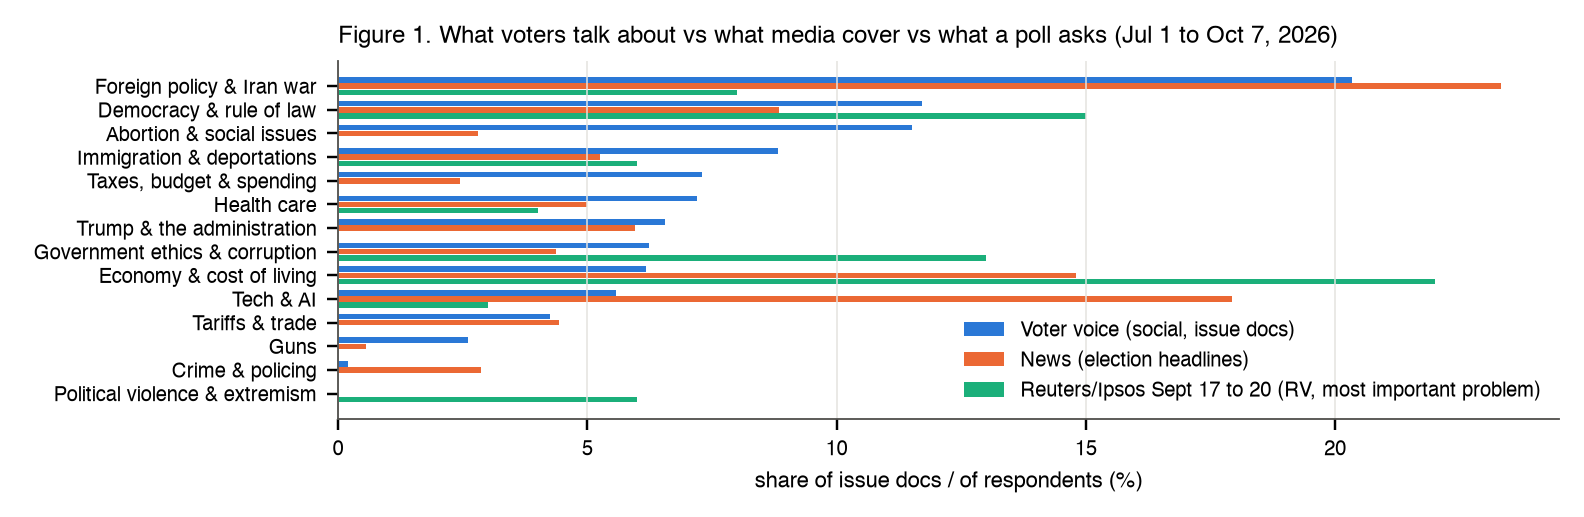

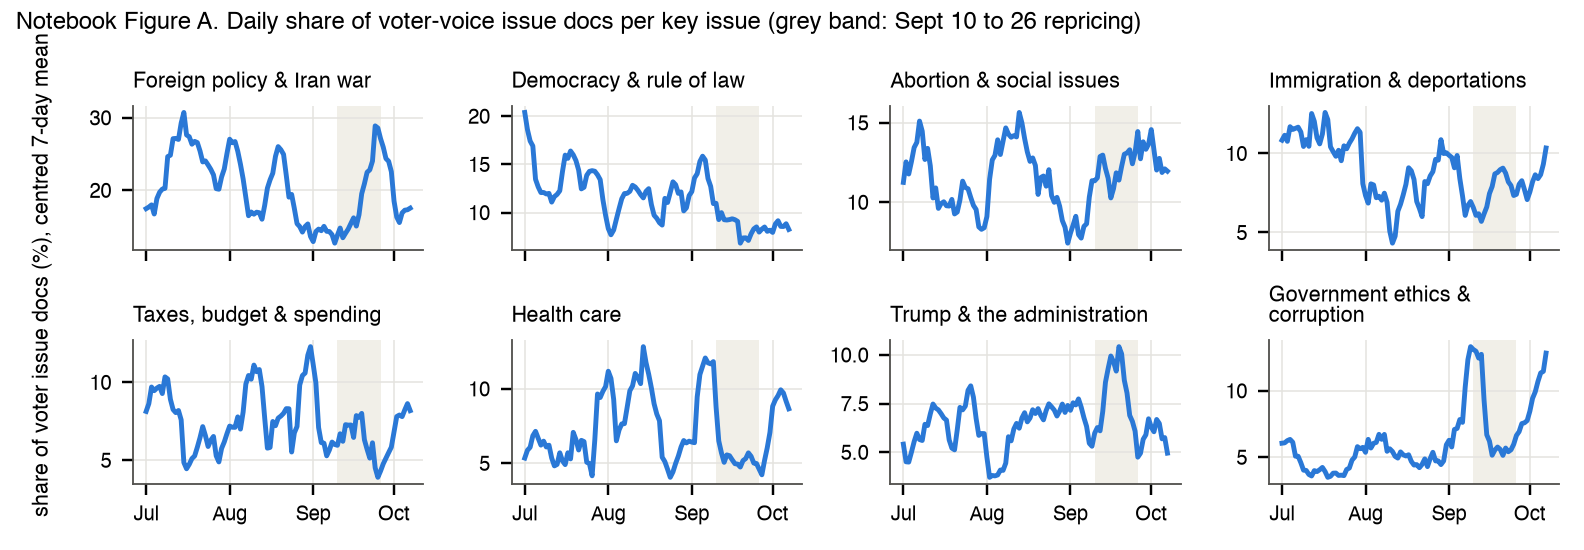

In [5]:
# topic table: every BERTopic topic with its LLM label, top words, share of all docs and one example
from src.config import LABELS
tt = pd.read_csv(LABELS / 'topic_taxonomy.csv').merge(pd.read_csv(LABELS / 'topic_sheet.csv'), on='topic')
tt['share_all_docs_%'] = (100 * tt['n_docs'] / len(pd.read_parquet('data/interim/doc_topics.parquet'))).round(2)
pd.set_option('display.max_colwidth', 120)
display(tt[['topic', 'label', 'short_name', 'confidence', 'share_all_docs_%', 'top_words', 'example_1']].sort_values(['label', 'share_all_docs_%'], ascending=[True, False]))
display((pd.read_csv(TABLES / 'q1_issue_shares.csv', index_col=0) * 100).round(1))
display(pd.read_csv(TABLES / 'q1_poll_compare.csv').round(2))
display((pd.read_csv(TABLES / 'q1_seed_stability.csv', index_col=0) * 100).round(1))
for f in ['fig1_issue_shares.png', 'figA_salience_over_time.png']:
    display(Image(filename=str(FIGURES / f), width=950))

**How these figures are made (Q1).** Every doc has a BERTopic topic (or -1, an outlier). The LLM taxonomy (`data/labels/topic_taxonomy.csv`) maps each of the 61 topics to an issue, horse race, media or noise. Figure 1 takes the voter-voice social docs (comments, self-posts, non-media tweets) dated Jul 1 to Oct 7 whose topic is an issue, and divides the count per issue by the count over all issues; the news bars do the same for election headlines; the green bars are the Reuters/Ipsos percentages. Notebook Figure A (moved out of the report to keep it at 6 pages with legible figures) is the same share computed day by day, with a centred 7-day mean. No sentiment score is used in either, and both are descriptive, not predictions.

## 5. Q2: A module that measures sentiment on those issues over time

*Readings used:* Carvalho and Plastino (2020), Psomakelis et al. (2014) and the autism-awareness slides on why tools disagree and need validation; Souza et al. (2015) for daily sentiment series.

![Figure 2](outputs/figures/fig2_directional_index.png)
*Figure 2. Directional index per key issue and composite C (centred 7-day means; daily series as in Souza et al.): source-weighted mean direction (tweets: NLI; Reddit: RoBERTa x τ), demeaned by issue and source (+ = more pro-Democrat than usual). Grey: Sept 10 to 26. Descriptive.*

**Result.** Partly. Per post, the tools it uses get direction right with fair agreement (macro-F1 0.60, κ 0.38 on 110 social posts, vs 0.22 for a majority guess); the composite uses 18,831 voter docs (median 189 a day; each key issue has 5+ docs on 94% to 100% of days). But **as a daily series it is mostly noise**: over 50 random splits of each day's posts into halves, the half-composites correlate at r = 0.08 on average (range -0.05 to 0.22; Spearman-Brown 0.15). Its versions agree (r 0.94 equal weights, 0.99 expanding weights, 0.99 adding the economy, 0.80 all social posts, 0.75 the 20-doc minimum, 0.71 RoBERTa only) and differ from plain tone (r = -0.22); it hardly trends (first- and second-half means 0.001 and -0.002; sd 0.038).

*Against the class readings:* as in Carvalho and Plastino (2020) and Psomakelis et al. (2014), tools disagree and the lexicon (VADER) is last for direction and tone.

*Why this result:* direction is harder than tone (0.60 vs 0.71), and about 189 posts a day are split over 8 issues and 7 sources (median non-empty cell: 3 posts); who posts that day moves the mean more than any shift in mood, and demeaning by source removes only the fixed lean.

**In short.** The directional module works per post with fair accuracy and a clear rule for which tool is used where, but at a daily horizon it carries little signal (split-half r 0.08), which sets a low ceiling for Q3 and Q4.

docs in index: 18831 | median docs/day: 189.0
coverage (share of days with >= 5 docs): {'Foreign policy & Iran war': 1.0, 'Democracy & rule of law': 1.0, 'Abortion & social issues': 1.0, 'Immigration & deportations': 1.0, 'Taxes, budget & spending': 0.99, 'Health care': 0.939, 'Trump & the administration': 1.0, 'Government ethics & corruption': 0.97}
split-half reliability: {'r_level_mean': 0.07907720752653359, 'r_level_sd': 0.07257872184580393, 'r_level_min': -0.05222710786008132, 'r_level_max': 0.22284533881348315, 'r_change_mean': 0.11887576013123075, 'sb_level_of_mean': 0.14656450340155877, 'n_seeds': 50}
correlation of C with its alternatives: {'C': 1.0, 'C_equal_w': 0.935, 'C_pooled': 0.787, 'C_all_social': 0.796, 'C_rob_tgt_only': 0.706, 'C_tone_nondirectional': -0.217, 'C_expanding_w': 0.994, 'C_with_economy': 0.986, 'C_min20_prereg': 0.75}


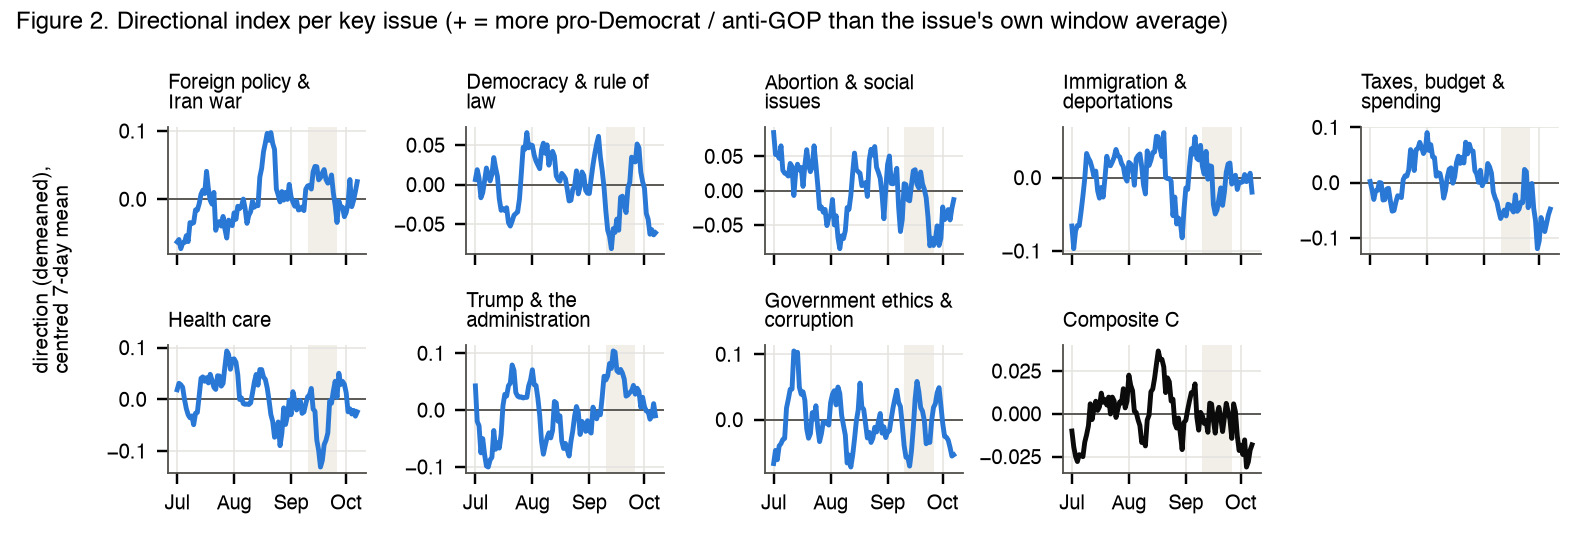

In [6]:
print('docs in index:', R['q2']['docs_in_index'], '| median docs/day:', R['q2']['docs_per_day_median'])
print('coverage (share of days with >= 5 docs):', R['q2']['coverage_ge5'])
print('split-half reliability:', R['q2']['split_half'])
print('correlation of C with its alternatives:', R['q2']['corr_C_with_alternatives'])
display(Image(filename=str(FIGURES / 'fig2_directional_index.png'), width=950))

**How Figure 2 is made (Q2).** Each voter doc gets a direction score: NLI s = P(pro-D) - P(pro-R) for tweets, (P_pos - P_neg) x tau for Reddit. For each key issue, source (Twitter and each subreddit) and day, the mean score is demeaned within that issue and source, then the sources are combined with fixed weights (their share of docs over the window). That gives the issue lines. The composite C weights the 8 issues by their Q1 voter shares. Lines are centred 7-day means; the tests use the daily values. Descriptive.

## 6. Q3: Does issue sentiment move with the probability of a Democratic sweep?

*Readings used:* Souza et al. (2015) for testing both directions and reporting each lag. External: Snowberg, Wolfers and Zitzewitz (2007) on prediction-market prices as probabilities.

![Figure 3](outputs/figures/fig3_sweep_index.png)
*Figure 3. (a) P(Democratic sweep) at 16:00 ET, Polymarket and Kalshi bid/ask mid. (b) Composite C, daily and centred 7-day mean, in its own panel (no second axis). (c) corr(C on day t-j, ΔP on day t), Polymarket, the lead-lag view in Souza et al.; dashed lines are ±1.96/√N. Grey band: the Sept 10 to 26 repricing. Panels (a) and (b) are descriptive; (c) is the lead-lag test, not a prediction.*

**Result.** No. The odds rose from 42.5% (Jul 1) to 63.5% (Oct 7), peak 66.5% on Oct 4, mostly in Sept 13 to 23, but the index does not move with them: **r = 0.067** with the daily change (N = 99). C is stationary (ADF p < 0.001, KPSS p ≥ 0.10), so by the pre-set rule its level is tested against ΔP (the odds have a unit root, ADF p = 0.97).

**Table 5. Family A, C_t vs ΔP_t (Polymarket), N = 96 to 99 days**

| Test | Lag | Pearson r / sum of coefs | HAC p | Permutation p | BH q |
|---|---|---|---|---|---|
| Same day | 0 | r = 0.067 | 0.58 | 0.53 | 0.68 |
| C → ΔP | 1 / 2 / 3 | -1.07 / -6.84 / -6.79 | 0.69 / 0.06 / 0.09 | 0.74 / 0.13 / 0.17 | 0.69 / 0.31 / 0.31 |
| ΔP → C | 1 / 2 / 3 | -0.002 / -0.006 / -0.010 | 0.56 / 0.58 / 0.14 | 0.63 / 0.59 / 0.30 | 0.68 / 0.68 / 0.32 |

- **No test passes the claim rule** (none has q < 0.10); r = 0.067 is far below what 99 days can detect (r* = 0.28). Same-day r is -0.036 on Kalshi, 0.04 with the economy added, and 0.15 (p = 0.16) with the 20-doc minimum; the secondary test in changes (ΔC vs ΔP) is null (r = 0.069, smallest p 0.11).
- The lowest p-values (C → ΔP, lags 2 and 3) have the **opposite** sign; the VAR(3) response agrees at day 2 (-0.20 points, 90% band -0.38 to -0.01), though AIC and BIC both pick 0 lags. It vanishes with the 20-doc minimum (p = 0.95). In the grid 21 of 93 tests have p < 0.10, all negative, but shifted index series give 17.0 such hits on average (21+ in 30%), so the count is chance; the strongest (trading-day ΔP → C, lag 3, within-spec q = 0.016) is wrong-signed too.
- The ceiling is low anyway: the two venues' daily changes correlate at only 0.40, and the odds do not move on 57% of days.

*Against Souza et al.:* they find Twitter sentiment Granger-causes some retail stocks' returns at a 1-day lag; here neither direction works at lag 1, and the lag-2 pattern has the wrong sign.

*Why this result:* the repricing coincided with polls (NYT/Siena Sept 15, state Senate polls), a ratings change (Cook, Sept 23) and high gas prices ($4.48 on Sept 24), which traders read directly, while posters argue about the same war and courts daily; a noisy index against odds that move in steps on few days leaves little room for a link.

**In short.** Text sentiment on the key issues did not lead, follow or move with the sweep odds at a daily horizon (r = 0.067); the one pattern is fragile and wrong-signed, and the test had little power to begin with.

stationarity: {
 "C": {
  "N": 99,
  "ADF_p": 3.701827469857301e-20,
  "KPSS_p": 0.1,
  "stationary": true
 },
 "dC": {
  "N": 98,
  "ADF_p": 1.6480240662049446e-11,
  "KPSS_p": 0.1,
  "stationary": true
 },
 "p_level": {
  "N": 99,
  "ADF_p": 0.9678216555897823,
  "KPSS_p": 0.01,
  "stationary": false
 },
 "dP": {
  "N": 99,
  "ADF_p": 3.2793495773227916e-14,
  "KPSS_p": 0.1,
  "stationary": true
 }
}


,spec,test,direction,lag,N,pearson_r,spearman_r,coef,p_hac,p_perm,p_F,q_bh
0,primary: C vs dP Polymarket,same-day,dP ~ sent,0,99,0.0673,0.0311,1.3954,0.5755,0.5349,NaN,0.6792
1,primary: C vs dP Polymarket,granger,sent -> dP,1,98,NaN,NaN,-1.0688,0.6925,0.7442,0.6887,0.6925
2,primary: C vs dP Polymarket,granger,dP -> sent,1,98,NaN,NaN,-0.0021,0.5620,0.6279,0.6249,0.6792
3,primary: C vs dP Polymarket,granger,sent -> dP,2,97,NaN,NaN,-6.8363,0.0592,0.1279,0.1335,0.3129
4,primary: C vs dP Polymarket,granger,dP -> sent,2,97,NaN,NaN,-0.0056,0.5822,0.5930,0.5686,0.6792
5,primary: C vs dP Polymarket,granger,sent -> dP,3,96,NaN,NaN,-6.7913,0.0894,0.1744,0.2414,0.3129
6,primary: C vs dP Polymarket,granger,dP -> sent,3,96,NaN,NaN,-0.0097,0.1382,0.3023,0.3915,0.3225


claim checks: [{'test': 'same-day', 'direction': 'dP ~ sent', 'lag': 0, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'sent -> dP', 'lag': 1, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'dP -> sent', 'lag': 1, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'sent -> dP', 'lag': 2, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'dP -> sent', 'lag': 2, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'sent -> dP', 'lag': 3, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'dP -> sent', 'lag': 3, 'pre_checks_pass': False}]


,spec,test,direction,lag,N,pearson_r,spearman_r,coef,p_hac,p_perm,p_F,q_bh
2,Kalshi mid,granger,dP -> sent,1,98,NaN,NaN,-0.0044,0.0934,NaN,0.2406,0.2701
3,Kalshi mid,granger,sent -> dP,2,97,NaN,NaN,-5.3565,0.0870,NaN,0.1611,0.2701
10,venue average,granger,sent -> dP,2,97,NaN,NaN,-5.9430,0.0182,NaN,0.0585,0.1090
12,venue average,granger,sent -> dP,3,96,NaN,NaN,-7.7144,0.0311,NaN,0.1054,0.1090
17,dlogit Polymarket,granger,sent -> dP,2,97,NaN,NaN,-0.2807,0.0564,NaN,0.1299,0.2971
19,dlogit Polymarket,granger,sent -> dP,3,96,NaN,NaN,-0.2759,0.0849,NaN,0.2330,0.2971
30,C_equal_w,granger,dP -> sent,1,98,NaN,NaN,-0.0063,0.0842,NaN,0.1486,0.1614
31,C_equal_w,granger,sent -> dP,2,97,NaN,NaN,-6.8430,0.0571,NaN,0.0995,0.1614
33,C_equal_w,granger,sent -> dP,3,96,NaN,NaN,-6.9999,0.0922,NaN,0.1604,0.1614
34,C_equal_w,granger,dP -> sent,3,96,NaN,NaN,-0.0138,0.0355,NaN,0.2450,0.1614


robust p<0.10: 21 of 93 | detectable r: 0.278 | venue daily corr: 0.397 | venue gap: {'min': -1.0000000000000009, 'max': 6.000000000000005, 'mean': 1.6565656565656577}
VAR impulse response of dP to an index shock: [0.066, -0.067, -0.199, -0.06, -0.028, -0.012, -0.006, -0.007]


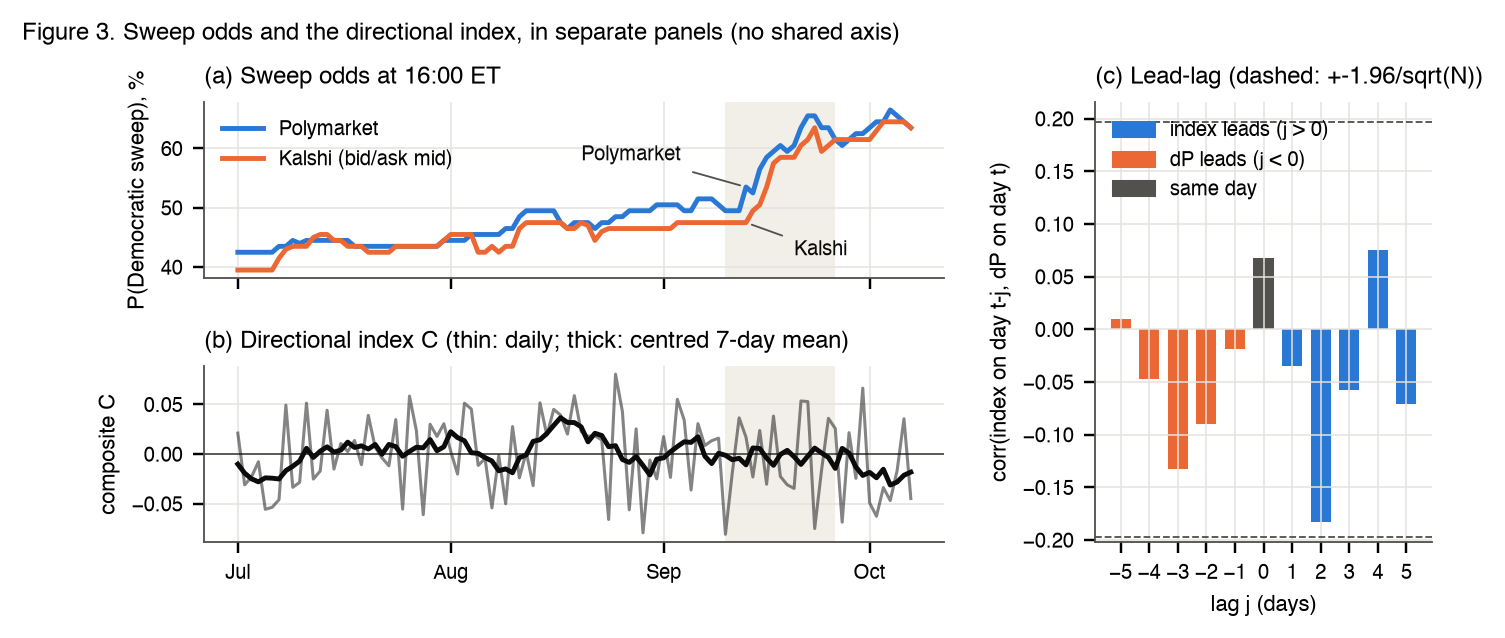

In [7]:
print('stationarity:', json.dumps(R['q3']['stationarity'], indent=1))
display(pd.read_csv(TABLES / 'q3_family_a.csv').round(4))
print('claim checks:', R['q3']['claims'])
g = pd.read_csv(TABLES / 'q3_robustness_grid.csv'); display(g[g.p_hac < 0.10].round(4))
print('robust p<0.10:', R['q3']['robust_count_p_lt_0.10'], 'of', R['q3']['robust_tests'], '| detectable r:', round(R['q3']['mde_r_N'], 3),
      '| venue daily corr:', round(R['q3']['venue_daily_corr'], 3), '| venue gap:', R['q3']['venue_gap_pp'])
print('VAR impulse response of dP to an index shock:', [round(x, 3) for x in R['q3']['var']['irf_dP_to_sent_shock']])
display(Image(filename=str(FIGURES / 'fig3_sweep_index.png'), width=950))

**How Figure 3 is made (Q3).** Panel (a) is the last hourly price at or before 16:05 ET each day (Polymarket's price; Kalshi's bid/ask mid). Panel (b) is the daily composite C from Q2 in its own panel, so there is no second y-axis. Panel (c) is the correlation of C shifted by j days with the daily change in the Polymarket price; blue bars (j > 0) are the index leading, orange bars the odds leading. It is a test, not a prediction.

## 7. Q4: Which stocks are exposed, and does the basket move with sentiment?

*Readings used:* Rigobon and Sack (2003), the class reading on how a political risk moves asset prices, with Rigobon (2003) for the identification idea. External: MacKinlay (1997), Knight (2006), Snowberg et al. (2007).

A **basket** is a group of stocks held together (equal weights): a **long leg** expected to gain from a sweep, a **short leg** expected to lose, and **long minus short**, which nets out the market and leaves the election bet; returns are **market-adjusted**, AR = r - β x SPY (β from Aug 2025 to Jun 2026).

**Table 6. The mid-term basket (signs fixed before any test-window data; γ = % abnormal return per +1 point of P(sweep), Aug 2025 to Jun 2026, N = 229)**

| Leg | Group: names | Why a sweep matters, with a Republican veto | γ | Expected sign (pre-window) |
|---|---|---|---|---|
| Long | ACA/Medicaid insurers: OSCR, CNC, MOH | ACA credits expired Dec 31, 2025; a House extension died in the Senate | +0.36 | 3 of 3 |
| Long | Hospitals: HCA, THC, UHS, CYH | exchange-loss hits (HCA $1.0 to 1.2B); HCA, UHS, CYH cut 2026 guidance | +0.14 | 4 of 4 |
| Long | Guns: RGR, SWBI | +12% and +18% when the 2021 Georgia runoffs gave D the Senate | +0.23 | 2 of 2 |
| Short | Detention: GEO, CXW | ICE was 47.6% and 35% of 2025 revenue; money needs Congress | +0.07 | 0 of 2 |
| Short | Defense: LMT, NOC, GD, HII | $350B of the $1.5T FY27 request needs a GOP reconciliation bill | -0.01 | 1 of 4 |
| Short | Crypto: COIN, HOOD | CLARITY Act failed cloture on Sept 15, no Democratic votes | +0.14 | 0 of 2 |

The long leg has some pre-window support (γ = +0.24, SE 0.12, p = 0.055; CNC and MOH clear of zero), gone on the Jan to Jun venue-average window (γ 0.03, p = 0.82); the **short leg rests on the policy mechanism only** (1 of 8 names with the expected sign; γ +0.05, p = 0.53). Oil, clean energy and tariff retail (10 names) are a "weak" sub-basket, as their lever is fixed by statute or executive action; pharma and banks are out (both parties push drug prices; regulators set capital rules). Per-name γ in the notebook.

![Figure 4](outputs/figures/fig4_basket.png)
*Figure 4. (a) Cumulative market-adjusted return of the equal-weighted long leg, short leg and long minus short, from 0 on Jun 30. (b) Polymarket P(sweep) in its own panel. Grey band: the Sept 10 to 26 repricing. No class paper has this exact figure. Descriptive; the tests are in the text.*

**Table 7. Sentiment index C vs the basket's market-adjusted long-minus-short return (trading days)**

| Test | Lag | Pearson r / sum of coefs | HAC p | Permutation p | BH q |
|---|---|---|---|---|---|
| Same day | 0 | r = -0.015 (Spearman 0.002) | 0.49 | 0.89 | 0.57 |
| C → basket | 1 / 2 / 3 | -6.05 / -11.10 / -8.72 | 0.21 / 0.18 / 0.23 | 0.23 / 0.32 / 0.48 | 0.40 / 0.40 / 0.40 |
| Basket → C | 1 / 2 / 3 | -0.002 / -0.003 / 0.003 | 0.38 / 0.67 / 0.21 | 0.48 / 0.70 / 0.54 | 0.53 / 0.67 / 0.40 |

**Result.** No, the sentiment index and the basket are not related: **r = -0.015** (N = 69) and no test passes; the 8 of 49 robustness hits are fewer than a shifted null gives (10.4), and the three within-spec hits (the factor-adjusted weak basket leading sentiment at lags 1 to 3, each q = 0.073) fail the permutation (p 0.13 to 0.39) and episode checks. Nor does the basket move with the odds: slope on ΔP 0.05 (SE 0.16, r = 0.03) on Polymarket, 0.17 (p = 0.22) on Kalshi; the Rigobon and Sack estimate from the 12 repricing days (ΔP variance 5.0 times higher) is +0.34, 95% CI -0.61 to 1.24 (0.31 without the Fed-hike day; days picked from the odds, not dated news).
- **The window total is an endpoint effect.** Long minus short ended at **+6.4%** (long +3.4%, short -2.9%; +4.3% against sector factors), but it was -2.4% on Sept 9, gained 2.3% in the repricing (odds 50.5% on Sept 9 to 63.5% on Sept 25), stood at **-0.3% on Oct 1** after the whole 21-point rise, then gained **6.6% in Oct 2 to 7** (1.6 on Oct 7) while the odds stayed within 63.5% to 66.5% and ended at 63.5%. So the total says nothing about the election.
- In the test window only 8 of 17 names move with the expected sign; per name (BH over 27) only RUN (+0.82, q = 0.002, expected) and DLTR (-0.62, q = 0.002, opposite) move with ΔP, both weak sub-basket; insurers and hospitals do not (slopes -0.22 to +0.30). OSCR's sign is unclear (it gained ACA members); without it the basket made +5.8%. Single names and sectors dominate (THC +30%, CYH -26%, MOH -15%; the weak sub-basket -41% market-adjusted but -8% against its factors, as oil rose with USO +35% and clean energy fell with ICLN -15.5%).

*Against Rigobon and Sack:* they sign war risk's effect (equities down, oil up) from high-variance news days; ours also carry 5 times the ΔP variance, but the basket's response is too noisy to sign. *Against Knight (2006):* he finds firm-level effects in 2000 (tobacco +13%, alternative energy -16%); our pre-window long leg fits that, the test window does not.

*Why this result:* with a Republican veto a sweep changes few laws, so the effect per point is small and single-stock noise hides it; a mostly-noise daily index caps any correlation.

**In short.** I can name exposed stocks with a policy reason, and the long side (insurers, hospitals) had some pre-window price support, but in the test window neither the sentiment index (r = -0.02) nor the odds (r = 0.03) line up with the basket, and its +6.4% total is an endpoint effect.

,group,expected_sign,beta,gamma_coef,gamma_se,gamma_ci90_lo,gamma_ci90_hi,sign_match
ticker,,,,,,,,
GEO,detention,-1,0.854,0.121,0.204,-0.215,0.456,False
CXW,detention,-1,0.522,0.024,0.152,-0.226,0.275,False
LMT,defense,-1,0.105,0.008,0.089,-0.138,0.155,False
NOC,defense,-1,0.056,0.001,0.075,-0.122,0.125,False
GD,defense,-1,0.434,0.001,0.062,-0.101,0.104,False
HII,defense,-1,0.697,-0.033,0.133,-0.251,0.186,True
COIN,crypto,-1,3.136,0.180,0.181,-0.117,0.477,False
HOOD,crypto,-1,3.041,0.104,0.205,-0.234,0.442,False
OSCR,aca_insurers,1,1.560,0.459,0.287,-0.014,0.931,True


,strength,expected_sign,n_names,gamma,se,t,p,N,sign_match
group,,,,,,,,,
detention,strong,-1,2,0.072,0.163,0.445,0.656,458,False
defense,strong,-1,4,-0.005,0.079,-0.069,0.945,916,True
crypto,strong,-1,2,0.142,0.163,0.871,0.384,458,False
aca_insurers,strong,1,3,0.358,0.213,1.678,0.093,687,True
hospitals,strong,1,4,0.145,0.117,1.242,0.214,916,True
guns,strong,1,2,0.233,0.206,1.131,0.258,458,True
oil_gas,weak,-1,3,0.083,0.089,0.936,0.349,687,False
clean_energy,weak,1,4,0.054,0.188,0.288,0.774,916,True
tariff_retail,weak,1,3,0.046,0.116,0.398,0.691,687,True


,coef,se,t,p,N,ci90_lo,ci90_hi
strong_ls,0.184,0.148,1.243,0.214,229.0,-0.060,0.428
strong_long,0.235,0.123,1.918,0.055,229.0,0.033,0.437
strong_short,0.051,0.080,0.636,0.525,229.0,-0.081,0.183
weak_ls,-0.033,0.182,-0.179,0.858,229.0,-0.332,0.267
strong_ls_no_OSCR,0.157,0.145,1.082,0.279,229.0,-0.081,0.395


,basket,leg,venue,coef,se,t,p_hac,N,pearson_r
0,strong,ls,poly_p,0.048,0.163,0.296,0.767,69,0.031
1,strong,ls,kal_p,0.167,0.135,1.231,0.218,69,0.119
2,strong,ls,avg_p,0.150,0.175,0.854,0.393,69,0.089
9,weak,ls,poly_p,0.216,0.196,1.104,0.270,69,0.101
10,weak,ls,kal_p,0.170,0.243,0.702,0.483,69,0.088
11,weak,ls,avg_p,0.252,0.227,1.108,0.268,69,0.108
18,strong_noOSCR,ls,poly_p,0.059,0.177,0.331,0.741,69,0.037
19,strong_noOSCR,ls,kal_p,0.153,0.142,1.072,0.284,69,0.106
20,strong_noOSCR,ls,avg_p,0.145,0.187,0.779,0.436,69,0.084
27,strong_factor,ls,poly_p,0.026,0.188,0.138,0.890,69,0.019


,d,var_shift,N_H,N_L,ci95_lo,ci95_hi,var_ratio_H_over_L
strong,0.344,2.543,12.0,57.0,-0.608,1.244,5.025
weak,0.512,2.543,12.0,57.0,-0.889,2.768,5.025
strong_factor,0.333,2.543,12.0,57.0,-0.692,1.374,5.025
weak_factor,0.195,2.543,12.0,57.0,-0.621,1.651,5.025
strong_long,0.082,2.543,12.0,57.0,-0.619,0.734,5.025
strong_short,-0.262,2.543,12.0,57.0,-1.102,0.420,5.025
strong_drop_Sep16,0.310,2.768,11.0,57.0,-0.523,1.229,5.382


,spec,test,direction,lag,N,pearson_r,spearman_r,coef,p_hac,p_perm,p_F,q_bh
0,sentiment vs strong L/S AR (trading days),same-day,LS ~ sent,0,69,-0.0153,0.0016,-4.1666,0.4856,0.8929,NaN,0.5665
1,sentiment vs strong L/S AR (trading days),granger,sent -> LS,1,68,NaN,NaN,-6.0512,0.2050,0.2321,0.2750,0.4023
2,sentiment vs strong L/S AR (trading days),granger,LS -> sent,1,68,NaN,NaN,-0.0021,0.3789,0.4821,0.4868,0.5304
3,sentiment vs strong L/S AR (trading days),granger,sent -> LS,2,67,NaN,NaN,-11.1035,0.1787,0.3214,0.3973,0.4023
4,sentiment vs strong L/S AR (trading days),granger,LS -> sent,2,67,NaN,NaN,-0.0025,0.6745,0.6964,0.7565,0.6745
5,sentiment vs strong L/S AR (trading days),granger,sent -> LS,3,66,NaN,NaN,-8.7222,0.2299,0.4821,0.5711,0.4023
6,sentiment vs strong L/S AR (trading days),granger,LS -> sent,3,66,NaN,NaN,0.0033,0.2077,0.5357,0.5075,0.4023


,ticker,group,expected_sign,test_coef,test_se,test_t,test_p_hac,test_N,pre_gamma,pre_gamma_se,beta_spy,cum_ar_window
0,GEO,detention,-1,-0.158,0.343,-0.461,0.645,69,0.121,0.204,0.854,-0.394
1,CXW,detention,-1,-0.430,0.456,-0.943,0.346,69,0.024,0.152,0.522,2.417
2,LMT,defense,-1,0.113,0.147,0.764,0.445,69,0.008,0.089,0.105,-1.859
3,NOC,defense,-1,0.077,0.130,0.594,0.553,69,0.001,0.075,0.056,-7.085
4,GD,defense,-1,-0.015,0.099,-0.150,0.881,69,0.001,0.062,0.434,-9.516
5,HII,defense,-1,0.113,0.131,0.860,0.390,69,-0.033,0.133,0.697,-9.606
6,COIN,crypto,-1,-0.187,0.328,-0.571,0.568,69,0.180,0.181,3.136,6.629
7,HOOD,crypto,-1,0.104,0.196,0.531,0.595,69,0.104,0.205,3.041,-4.105
8,OSCR,aca_insurers,1,-0.081,0.303,-0.267,0.790,69,0.459,0.287,1.560,7.694
9,CNC,aca_insurers,1,-0.116,0.189,-0.612,0.540,69,0.313,0.166,0.320,-0.118


cumulative AR at Oct 7 (%): {'strong': 6.351, 'weak': -41.201, 'strong_noOSCR': 5.816, 'strong_factor': 4.267, 'weak_factor': -7.854, 'gate': 6.89, 'long': 3.412, 'short': -2.94} | provisional Oct 7 close: False


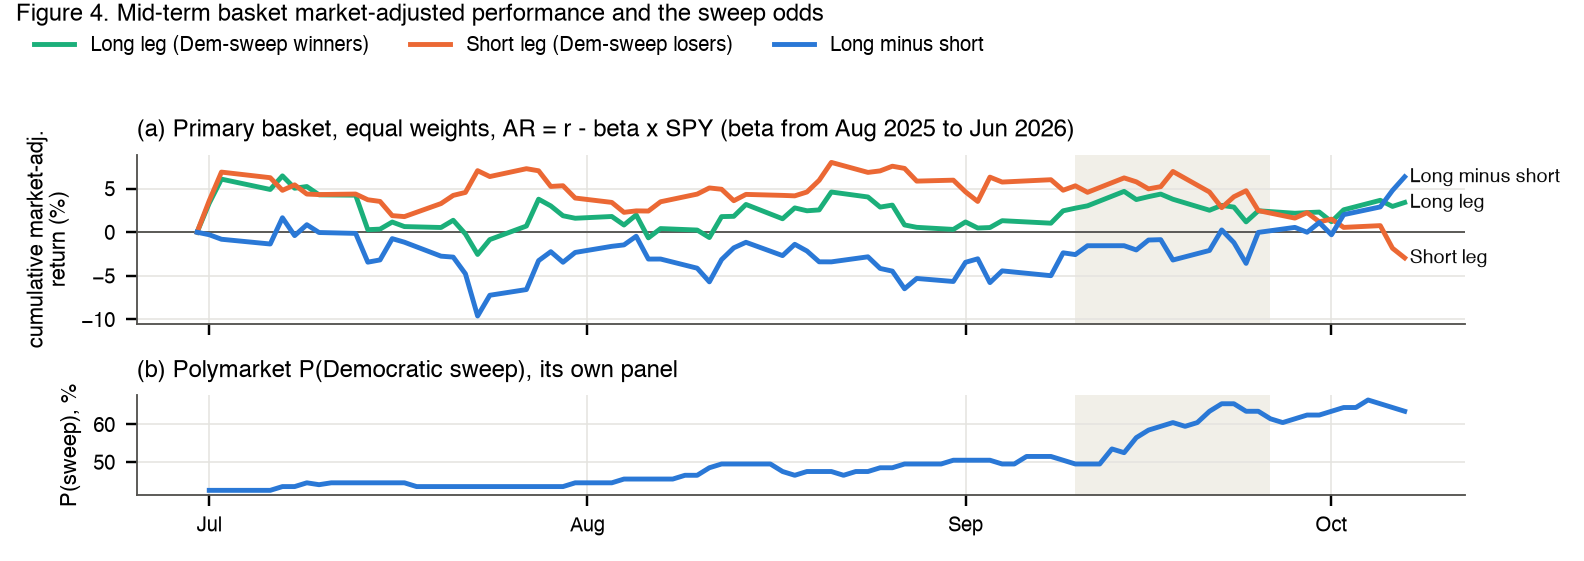

In [8]:
display(pd.read_csv(TABLES / 'q4_election_betas_main_poly.csv', index_col=0)[['group', 'expected_sign', 'beta', 'gamma_coef', 'gamma_se', 'gamma_ci90_lo', 'gamma_ci90_hi', 'sign_match']].round(3))
display(pd.read_csv(TABLES / 'q4_group_gamma_main_poly.csv', index_col=0).round(3))
display(pd.read_csv(TABLES / 'q4_basket_gamma_main_poly.csv', index_col=0).round(3))
v = pd.read_csv(TABLES / 'q4_validation_vs_dp.csv'); display(v[v.leg == 'ls'].round(3))
display(pd.read_csv(TABLES / 'q4_rigobon_sack.csv', index_col=0).round(3))
display(pd.read_csv(TABLES / 'q4_family_sent_vs_basket.csv').round(4))
display(pd.read_csv(TABLES / 'q4_per_name.csv').round(3))
print('cumulative AR at Oct 7 (%):', R['q4']['cum_ar_end'], '| provisional Oct 7 close:', R['q4']['provisional_oct7'])
display(Image(filename=str(FIGURES / 'fig4_basket.png'), width=950))

**How Figure 4 is made (Q4).** For each name, beta on SPY comes from daily log returns Aug 1, 2025 to Jun 30, 2026. In the test window AR = 100 x (r - beta x r_SPY), with no alpha. The long leg is the equal-weighted mean AR of the 9 names expected to gain from a sweep, the short leg of the 8 expected to lose, and the lines are cumulative sums from 0 on Jun 30. Panel (b) is the Polymarket price in its own panel. Descriptive.

## 8. Q5: What I conclude

*Readings used:* all of the above; the numbers are from Sections 4 to 7.

1. **What online posters argue about is not the polls' agenda.** In 12,567 voter-voice issue posts the economy is 5% to 9% in every model version against 22% to 31% in every poll, and foreign policy and democracy are always top three. Robust; the finer order is fragile. For a PM, polls and social text answer different questions; text shows what is argued about this week.
2. **Media cover a different agenda again.** In 23,045 election headlines the economy is 14.8% and markets or tech 17.9%, but social issues only 2.8% (posters 11.5%, a fragile share). Robust across outlet groups: every group is further from posters than posters' own shared links are (E1).
3. **A directional political-sentiment index can be built with fair per-post accuracy (macro-F1 0.60 vs 0.22 for a guess), but daily it is mostly noise** (split-half r 0.08, 189 docs a day). Do not trade on a daily political mood index of this size.
4. **No daily link between sentiment and the sweep odds** (r = 0.067, N = 99; 0 of 7 pre-registered tests pass). The low p-values have the wrong sign, vanish under the pre-registered 20-doc minimum, and their count is what chance gives (P = 0.30). Correlation and Granger are not causality in any case.
5. **No link between sentiment and the mid-term basket** (r = -0.02, N = 69; 0 of 7 tests pass), nor between the basket and the odds (r = 0.03). Its +6.4% is an endpoint effect (-0.3% on Oct 1), the short leg has no price support, and the long leg's is fragile. With a Republican veto the stakes per point of sweep probability are small; a PM should not read this basket as an election hedge.

**In short.** What people talk about is measurable and different from what polls and media show, but a daily political mood index of this size moves with neither the sweep odds nor the stocks the result would affect, and the basket's window gain is an endpoint effect, not an election effect.

## 9. Extra questions that came up

*Readings used:* Sacerdote et al. (2020) for E1; Souza et al. (2015) for the per-issue tests in E2; Rigobon and Sack (2003) for the event window in E3.

**E1. Do media and voters care about the same issues?** *Result:* no, business media least. Agenda distance from voter-voice posts (TVD; 0 = same, 1 = disjoint): posters' shared links 0.16, all news 0.27 (incl. the US feed), US left 0.21, right 0.21, centre 0.28, international 0.29, business 0.51. Right-leaning outlets rank issues closest to posters (Spearman 0.75; left 0.65, business 0.50), and the economy's share rises from posters (6.2%) to right (8.2%), left (9.9%), centre (16.0%) and business outlets (26.9%). *Why this result:* likely, partisan outlets cover the fights partisans post about, while business media cover prices, rates and markets; as in Sacerdote et al., the outlet group shapes what you see. *In short:* the further an outlet is from partisan politics, the further its agenda is from posters'.

**E2. Which single issue tracks the sweep odds most?** *Result:* none; over 9 issues (key 8 plus the economy) x 3 tests (BH over 27) the smallest q is 0.57 (Trump and the administration same-day p = 0.14; economy p = 0.27). *Why this result:* each issue's index has even fewer docs. *In short:* no hidden link by issue.

**E3. What happened during the Sept 10 to 26 repricing?** *Result:* the odds rose 11 points in 17 days, and attention shifted (vs Aug 24 to Sept 9): up for foreign policy (+4.0 points), economy (+3.5), social issues (+3.1), ethics (+2.7); down for democracy (-4.9), tariffs (-4.3), health care (-3.6). The index did not turn pro-Democrat (mean 0.002 before, -0.003 during). *Why this result:* the repricing coincided with polls and a ratings change, which traders watch; attention moved, each side kept its view. *In short:* the repricing shows up in what people talk about, not in which side they favour.

In [9]:
display(pd.read_csv(TABLES / 'e1_agenda_distance.csv').round(3))
display(pd.read_csv(TABLES / 'e2_issue_vs_sweep.csv').round(3))
display((pd.read_csv(TABLES / 'e3_issue_shift.csv', index_col=0)).round(4))
print({k: v for k, v in R['extras']['e3'].items() if k != 'xcorr_event'})

,group,tvd_vs_voter,spearman_vs_voter,economy_share,iran_share
0,shared_media,0.163,0.779,0.057,0.246
1,news,0.268,0.623,0.148,0.233
2,news_US_LEFT,0.207,0.652,0.099,0.234
3,news_US_RIGHT,0.212,0.753,0.082,0.294
4,news_US_CENTER,0.276,0.599,0.160,0.235
5,news_BUSINESS,0.512,0.502,0.269,0.169
6,news_INTL,0.287,0.588,0.144,0.288


,issue,same_day_coef,same_day_p_hac,N,granger_sent_to_dP_p_hac,granger_dP_to_sent_p_hac,same_day_q,g_sent_dP_q,g_dP_sent_q
0,Foreign policy & Iran war,-0.283,0.783,99,0.387,0.101,0.846,0.628,0.570
1,Democracy & rule of law,1.065,0.304,99,0.484,0.500,0.628,0.643,0.643
2,Abortion & social issues,0.397,0.701,99,0.190,0.177,0.788,0.570,0.570
3,Immigration & deportations,0.500,0.428,99,0.939,0.111,0.628,0.939,0.570
4,"Taxes, budget & spending",-0.084,0.930,99,0.159,0.403,0.939,0.570,0.628
5,Health care,-0.690,0.331,99,0.442,0.088,0.628,0.628,0.570
6,Trump & the administration,1.488,0.145,99,0.379,0.624,0.570,0.628,0.732
7,Government ethics & corruption,-0.433,0.574,99,0.403,0.062,0.704,0.628,0.570
8,Economy & cost of living,-1.012,0.266,97,0.251,0.175,0.628,0.628,0.570


,pre_mean_share,event_mean_share,change_pp
Foreign policy & Iran war,0.1466,0.1862,3.9536
Economy & cost of living,0.0764,0.1113,3.4825
Abortion & social issues,0.0930,0.1244,3.1460
Government ethics & corruption,0.0591,0.0859,2.6847
Tech & AI,0.0551,0.0811,2.5944
Trump & the administration,0.0694,0.0784,0.8946
Crime & policing,0.0033,0.0010,-0.2294
Education,0.0135,0.0101,-0.3328
Guns,0.0152,0.0119,-0.3345
"Taxes, budget & spending",0.0786,0.0645,-1.4138


{'C_pre_mean': 0.0019329243253320449, 'C_event_mean': -0.0028554623881795285, 'dP_event_sum_pp': 10.999999999999998, 'dP_pre_sum_pp': 3.0000000000000027}


## 10. Limitations

- **Sample and measurement.** Twitter is a paid sample of engaged tweets (7 empty windows); Reddit is six political subs, some heavily moderated; news is capped and dated only; none of it samples registered voters. 40% of docs are topic outliers; the taxonomy and all labels come from Claude subagents, not humans (κ 0.96 between two subagents, which may share biases); the index needed a disclosed deviation (5 docs per issue-day, not 20); τ counts "conservatives" and "liberals" as party names; tools were chosen and scored on the same 150 items; the topic model saw the whole window's text, never prices.
- **Power, timing and causality.** 99 days (69 trading days) detect only r ≥ 0.28 (0.33); Granger and correlation are not causality; confounders include the Fed hike, the Iran war's oil effect and earnings. Kalshi's snapshot is about an hour old on 2 window days, Polymarket's 1 to 6 hours on 14 pre-window days (without the 23 affected days the long-leg γ is 0.234, p = 0.064). No election-day test (due before Nov 3).

<p class="refs"><strong>References.</strong> Class readings: Bybee, Kelly, Manela and Xiu (2024), JF · Rigobon and Sack (2003), NBER WP 9609 · Rigobon (2003), REStat · Souza, Kolchyna, Treleaven and Aste (2015) · Sacerdote, Sehgal and Cook (2020), NBER WP 28110 · Carvalho and Plastino (2020) · Psomakelis et al. (2014) · autism-awareness slides; Bagheri; Yener (2020). External: Knight (2006), JPubE · Snowberg, Wolfers and Zitzewitz (2007), QJE · MacKinlay (1997), JEL · Grootendorst (2022) · Blei, Ng and Jordan (2003) · Röder et al. (2015) · Laurer et al. (2023) · Loureiro et al. (2022) · Hutto and Gilbert (2014) · Cohen (1960) · Spearman (1910); Brown (1910) · Granger (1969) · Newey and West (1987) · Benjamini and Hochberg (1995) · Said and Dickey (1984); Kwiatkowski et al. (1992) · Hubert and Arabie (1985) · Hulley et al. (2013) · Levin, Peres and Wilmer (2009) · Yuan and Shou (2024). Data and facts: Polymarket, Kalshi (APIs, rules); twitterapi.io; Arctic Shift; Google News RSS; Pew (Jul 23, 2026); Gallup MIP (Sept 2026); Reuters/Ipsos (Aug 28 to 31, Sept 17 to 20); KFF (Oct 6); 10-K/10-Q filings (GEO, CXW, CNC); Defense News; Breaking Defense; Newsweek; Fortune; NPR; AP; Federal Reserve (Sept 16); DOI; IRS.</p>